# **AML LAB**

## **Lab 2 (Experiment 1) - 02/02/2026**

## 1. Team Name Normalization
## Some team names appear in different textual formats (e.g., case differences or extra spaces). Clean the team1 and team2 columns by:
## (a) Converting text to lowercase
## (b) Removing leading/trailing spaces
## (c) Verifying unique team names after cleaning

In [ ]:
# Import required libraries
# pandas → for data handling
# matplotlib → for plotting
# seaborn → for advanced visualizations
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load the dataset from Google Drive
# This dataset contains IPL match records
df = pd.read_csv('/content/drive/MyDrive/Applied_ML_Lab/Lab_2/data.csv')

# Display full dataframe to understand structure
print(df)

      id  season        city        date                  team1  \
0      1    2008   Bangalore  2008-04-18  Kolkata Knight Riders   
1      2    2008  Chandigarh  2008-04-19    Chennai Super Kings   
2      3    2008       Delhi  2008-04-19       Rajasthan Royals   
3      4    2008      Mumbai  2008-04-20         Mumbai Indians   
4      5    2008     Kolkata  2008-04-20        Deccan Chargers   
..   ...     ...         ...         ...                    ...   
572  573    2016      Raipur  2016-05-22       Delhi Daredevils   
573  574    2016   Bangalore  2016-05-24          Gujarat Lions   
574  575    2016       Delhi  2016-05-25    Sunrisers Hyderabad   
575  576    2016       Delhi  2016-05-27          Gujarat Lions   
576  577    2016   Bangalore  2016-05-29    Sunrisers Hyderabad   

                           team2                  toss_winner toss_decision  \
0    Royal Challengers Bangalore  Royal Challengers Bangalore         field   
1                Kings XI Punjab     

In [ ]:
# Display team1 and team2 columns
# Used to observe text inconsistencies like:
# - Capital letters
# - Extra spaces
print(df['team1'], df['team2'])

0      Kolkata Knight Riders
1        Chennai Super Kings
2           Rajasthan Royals
3             Mumbai Indians
4            Deccan Chargers
               ...          
572         Delhi Daredevils
573            Gujarat Lions
574      Sunrisers Hyderabad
575            Gujarat Lions
576      Sunrisers Hyderabad
Name: team1, Length: 577, dtype: object 0      Royal Challengers Bangalore
1                  Kings XI Punjab
2                 Delhi Daredevils
3      Royal Challengers Bangalore
4            Kolkata Knight Riders
                  ...             
572    Royal Challengers Bangalore
573    Royal Challengers Bangalore
574          Kolkata Knight Riders
575            Sunrisers Hyderabad
576    Royal Challengers Bangalore
Name: team2, Length: 577, dtype: object


In [ ]:
# (a) Convert to lowercase
# (b) Remove leading/trailing spaces
# This standardizes team names so same teams don't appear as different entries

# Clean team1 column
df['team1'] = df['team1'].str.lower().str.strip()

# Clean team2 column
df['team2'] = df['team2'].str.lower().str.strip()

# Print cleaned values
print(df['team1'], df['team2'])

0      kolkata knight riders
1        chennai super kings
2           rajasthan royals
3             mumbai indians
4            deccan chargers
               ...          
572         delhi daredevils
573            gujarat lions
574      sunrisers hyderabad
575            gujarat lions
576      sunrisers hyderabad
Name: team1, Length: 577, dtype: object 0      royal challengers bangalore
1                  kings xi punjab
2                 delhi daredevils
3      royal challengers bangalore
4            kolkata knight riders
                  ...             
572    royal challengers bangalore
573    royal challengers bangalore
574          kolkata knight riders
575            sunrisers hyderabad
576    royal challengers bangalore
Name: team2, Length: 577, dtype: object


In [ ]:
# (c) Verify cleaning worked correctly
# unique() shows all distinct team names
# Helps confirm no duplicates due to case/spacing
print(df['team1'].unique())
print(df['team2'].unique())

['kolkata knight riders' 'chennai super kings' 'rajasthan royals'
 'mumbai indians' 'deccan chargers' 'kings xi punjab'
 'royal challengers bangalore' 'delhi daredevils' 'kochi tuskers kerala'
 'pune warriors' 'sunrisers hyderabad' 'rising pune supergiants'
 'gujarat lions']
['royal challengers bangalore' 'kings xi punjab' 'delhi daredevils'
 'kolkata knight riders' 'rajasthan royals' 'mumbai indians'
 'chennai super kings' 'deccan chargers' 'pune warriors'
 'kochi tuskers kerala' 'sunrisers hyderabad' 'rising pune supergiants'
 'gujarat lions']


##2. City Name Standardization
##Standardize the city column by:
##(a) Replacing missing city names with "Unknown"
##(b) Converting all city names to title case
##(c) Counting matches played in each city


In [ ]:
# Count number of missing values in city column
# We check this before filling them
print(df['city'].isnull().sum())

7


In [ ]:
# (a) Replace missing city names with "Unknown"
df['city'] = df['city'].fillna("Unknown")

# Verify no missing values remain
print(df['city'].isnull().sum())
print(df['city'].head())

0
0     Bangalore
1    Chandigarh
2         Delhi
3        Mumbai
4       Kolkata
Name: city, dtype: object


In [ ]:
# (b) Convert city names into Title Case
# Example: "mumbai" → "Mumbai"
df['city'] = df['city'].str.title()

print(df['city'].head())

0     Bangalore
1    Chandigarh
2         Delhi
3        Mumbai
4       Kolkata
Name: city, dtype: object


In [ ]:
# (c) Count matches played in each city
# value_counts() gives frequency of each city
df['city'].value_counts()

,count
city,
Mumbai,77
Bangalore,58
Kolkata,54
Delhi,53
Chennai,48
Chandigarh,42
Hyderabad,41
Jaipur,33
Pune,25


##3. Toss Decision Text Analysis
##Analyze the toss_decision column:
##(a) Extract unique decisions
##(b) Count how many times each decision was taken
##(c) Visualize the frequency using a bar chart

In [ ]:
# (a) Show all unique toss decisions
df['toss_decision'].unique()

array(['field', 'bat'], dtype=object)

In [ ]:
# (b) Count how many times each toss decision occurred
df['toss_decision'].value_counts()

,count
toss_decision,
field,315
bat,262


<Axes: xlabel='toss_decision'>

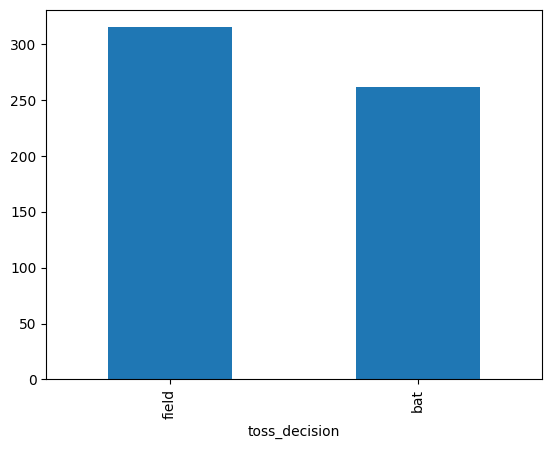

In [ ]:
# (c) Visualize toss decision frequency using bar chart
bar = df['toss_decision'].value_counts()
bar.plot(kind = "bar")

##4. Winner Name Extraction
##From the winner column:
##(a) Identify and remove rows where the match result was "No Result" or "Tie"
##(b) Count how many matches each team won after cleaning text values

In [ ]:
# Check different result types present in dataset
# Example: normal, tie, no result
df['result'].value_counts()

,count
result,
normal,568
tie,6
no result,3


In [ ]:
# (a) Keep only matches with normal results
# Removing 'tie' and 'no result'
df = df[df['result'] == 'normal']

# Verify filtering worked
df['result'].value_counts()

,count
result,
normal,568


In [ ]:
# (b) Count total wins by each team
df['winner'].value_counts()

,count
winner,
Mumbai Indians,80
Chennai Super Kings,79
Royal Challengers Bangalore,69
Kolkata Knight Riders,68
Rajasthan Royals,61
Kings XI Punjab,61
Delhi Daredevils,56
Sunrisers Hyderabad,33
Deccan Chargers,29


##5. Player of the Match Text Frequency
##Perform text analysis on player of the match:
##(a) Remove null values
##(b) Find the top 10 most frequent player names
##(c) Plot the results using a Seaborn bar plot


In [ ]:
# Get top 10 players who won 'Player of the Match' most times
top_player = df['player_of_match'].value_counts().head(10)
print(top_player)

player_of_match
CH Gayle          17
YK Pathan         15
AB de Villiers    15
DA Warner         14
RG Sharma         13
SK Raina          13
MS Dhoni          12
MEK Hussey        12
AM Rahane         12
G Gambhir         12
Name: count, dtype: int64


<Axes: ylabel='player_of_match'>

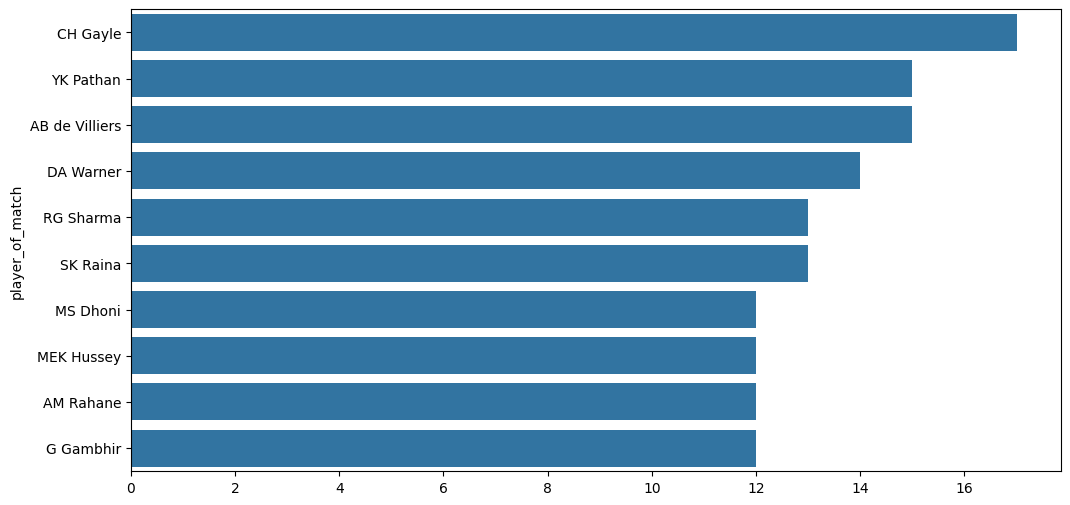

In [ ]:
# Plot top 10 players using seaborn barplot
plt.figure(figsize=(12,6))
sns.barplot(x=top_player.values, y=top_player.index)

##6. Venue Tokenization
##Count how many matches were played in each venue and plot a bar chart for the top 10.



In [ ]:
# Count matches played at each venue
df['venue'].value_counts().head(10)

,count
venue,
M Chinnaswamy Stadium,55
Eden Gardens,54
Feroz Shah Kotla,52
Wankhede Stadium,49
"MA Chidambaram Stadium, Chepauk",47
"Rajiv Gandhi International Stadium, Uppal",40
"Punjab Cricket Association Stadium, Mohali",35
Sawai Mansingh Stadium,33
Dr DY Patil Sports Academy,17


<Axes: xlabel='venue'>

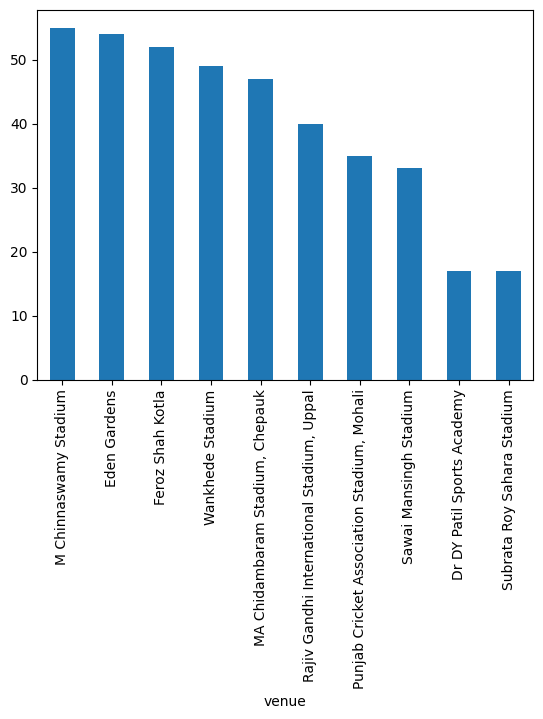

In [ ]:
# Plot top 10 venues by number of matches
bar = df["venue"].value_counts().head(10)
bar.plot(kind = "bar")

##7. Umpire Name Cleaning
##Clean umpire columns (umpire1, umpire2, umpire3) by:
##(a) Replacing missing values with "Not Assigned"
##(b) Removing duplicate umpire names per match
##(c) Finding the most frequently officiating umpire

In [ ]:
# Count missing values in umpire columns
print(df['umpire1'].isnull().sum())
print(df['umpire2'].isnull().sum())
print(df['umpire3'].isnull().sum())

0
0
568


In [ ]:
# (a) Replace missing umpire3 values with "Not Assigned"
df['umpire3'].fillna("Not Assigned", inplace = True)

/tmp/ipython-input-4146130111.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['umpire3'].fillna("Not Assigned", inplace = True)
/tmp/ipython-input-4146130111.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Not Assigned' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df['umpire3'].fillna("Not Assigned", inplace = True)


In [ ]:
# Verify missing values after replacement
print(df['umpire1'].isnull().sum())
print(df['umpire2'].isnull().sum())
print(df['umpire3'].isnull().sum())

0
0
0


In [ ]:
# Get unique umpire names from both columns
umpire1 = df["umpire1"].unique()
umpire2 = df["umpire2"].unique()

In [ ]:
# Display sample umpire names
print(df['umpire1'].head(10))
print(df['umpire2'].head(10))

0    Asad Rauf
1    MR Benson
2    Aleem Dar
3     SJ Davis
4    BF Bowden
5    Aleem Dar
6    IL Howell
7    DJ Harper
8    Asad Rauf
9    Aleem Dar
Name: umpire1, dtype: object
0       RE Koertzen
1        SL Shastri
2    GA Pratapkumar
3         DJ Harper
4       K Hariharan
5         RB Tiffin
6         AM Saheba
7    GA Pratapkumar
8         MR Benson
9         AM Saheba
Name: umpire2, dtype: object


##8. Create a new text column match_summary by combining:
##Team1, Team2, Winner, and Season
##Example: “MI vs CSK - MI won in 2019”
##Display sample summaries.

In [ ]:
# Create new column 'match_summary'
# Combines team1, team2, winner and season
# Example format:
# "MI vs CSK - MI won in 2019"

pd.set_option('display.max_colwidth', None)

df['match_summary'] = df['team1'].astype(str) + " vs " + df['team2'].astype(str) + " - " + df['winner'].astype(str) + " won in " + df['season'].astype(str)

print(df['match_summary'].head())

0    kolkata knight riders vs royal challengers bangalore - Kolkata Knight Riders won in 2008
1                    chennai super kings vs kings xi punjab - Chennai Super Kings won in 2008
2                         rajasthan royals vs delhi daredevils - Delhi Daredevils won in 2008
3     mumbai indians vs royal challengers bangalore - Royal Challengers Bangalore won in 2008
4                deccan chargers vs kolkata knight riders - Kolkata Knight Riders won in 2008
Name: match_summary, dtype: object


##9. Result Type Text Analysis
##Analyze the result column:
##(a) Identify different textual result types
##(b) Count their occurrences
##(c) Visualize the distribution using a count plot


In [ ]:
# (a) Identify unique match result types
print(df['result'].unique())

['normal']


In [ ]:
# (b) Count occurrences of each result type
print(df['result'].value_counts())

result
normal    568
Name: count, dtype: int64


<Axes: xlabel='result', ylabel='count'>

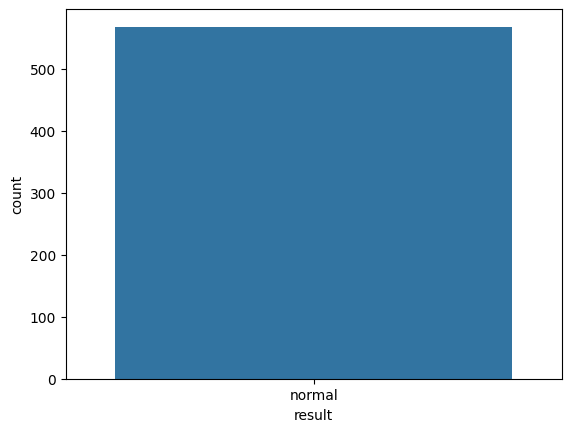

In [ ]:
# (c) Visualize distribution using countplot
sns.countplot(x=df['result'])

##10. Toss Winner vs Match Winner (Text Matching)
##Compare text values in toss_winner and winner:
##(a) Create a boolean column indicating whether the toss winner also won the match
##(b) Visualize the comparison using a bar chart

In [ ]:
# Clean text for accurate comparison
# Remove spaces + convert to lowercase
df['toss_winner'] = df['toss_winner'].str.strip().str.lower()
df['winner'] = df['winner'].str.strip().str.lower()

# (a) Create boolean column:
# True → toss winner also won the match
df['toss_won'] = df['toss_winner'] == df['winner']

print(df['toss_won'])

0      False
1       True
2      False
3      False
4      False
       ...  
572     True
573     True
574    False
575     True
576     True
Name: toss_won, Length: 568, dtype: bool


In [ ]:
# Count how many times toss winner also won match
print(df['toss_won'].value_counts())

toss_won
True     288
False    280
Name: count, dtype: int64


<Axes: xlabel='toss_won'>

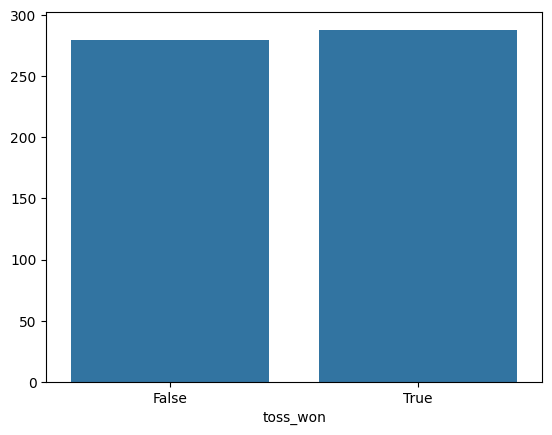

In [ ]:
# Visualize toss winner vs match winner comparison
sns.barplot(x = df['toss_won'].value_counts().index, y = df['toss_won'].value_counts().values)

##11. Winner points Graph
##X - team name, Y- No. Of win

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
 [Text(0, 0, 'mumbai indians'),
  Text(1, 0, 'chennai super kings'),
  Text(2, 0, 'royal challengers bangalore'),
  Text(3, 0, 'kolkata knight riders'),
  Text(4, 0, 'rajasthan royals'),
  Text(5, 0, 'kings xi punjab'),
  Text(6, 0, 'delhi daredevils'),
  Text(7, 0, 'sunrisers hyderabad'),
  Text(8, 0, 'deccan chargers'),
  Text(9, 0, 'pune warriors'),
  Text(10, 0, 'gujarat lions'),
  Text(11, 0, 'kochi tuskers kerala'),
  Text(12, 0, 'rising pune supergiants')])

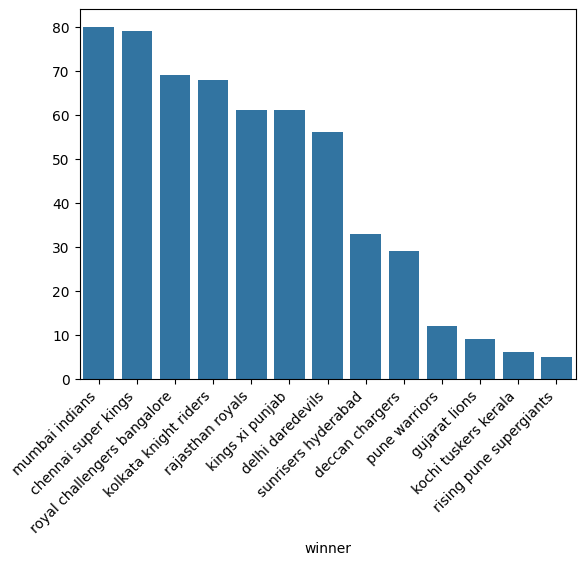

In [ ]:
# Plot number of wins per team
sns.barplot(x = df['winner'].value_counts().index, y = df['winner'].value_counts().values)

# Rotate labels for readability
plt.xticks(rotation = 45, ha = 'right')